# Closed-Loop Berthing Guidance

## tl;dr

This notebook compares three levels of decision support under identical disturbances: **no control → reactive control → predictive decision support**. The fixed berth, nominal path, initial state, environment, process noise, timestep, and termination rule are shared across policies.

> **Simulation only.** Thresholds, dynamics, and actions are educational abstractions—not certified navigation limits or real helm commands. A human operator retains authority.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
ASSETS = ROOT / "assets"
ASSETS.mkdir(exist_ok=True)

from src.simulator import DT_SECONDS, VesselState, generate_environment_series
from src.trajectory import generate_nominal_trajectory
from src.recommender import (
    CANDIDATE_ACTIONS, POLICY_LABELS, RULE_THRESHOLDS, classify_deviation,
    closed_loop_metrics, recommend_action, recommendation_reason,
    rule_based_action, run_closed_loop,
)

COLORS = {
    "plan": "#243B53", "Maintain only": "#D97706",
    "Rule-based path follower": "#6B7F2A", "Predictive recommender": "#146C94",
    "berth": "#7C3AED",
}
plt.rcParams.update({
    "figure.figsize": (10, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.22, "font.size": 10,
})
trajectory = generate_nominal_trajectory()
berth = pd.read_csv(ROOT / "data/sample/berth.csv").iloc[0]

## 1. Closed-Loop Guidance Problem

The planner defines where the vessel should go. Three policies then receive the same current state and simulation conditions:

1. **Maintain only:** no active correction; it isolates disturbance effects.
2. **Rule-based path follower:** reacts to current cross-track, heading, speed, and berth-distance errors.
3. **Predictive recommender:** simulates candidate actions over a short horizon and recommends the lowest-cost future.

This tests whether anticipation adds measurable value beyond simple reactive feedback. Every output remains advisory; the pilot or bridge crew accepts or overrides it.

## 2. Planned Trajectory

In [2]:
display(trajectory.iloc[::max(1, len(trajectory)//8)][
    ["x", "y", "desired_heading_deg", "desired_speed_mps", "along_track_progress"]
].round(2))
display(pd.DataFrame([berth]))

,x,y,desired_heading_deg,desired_speed_mps,along_track_progress
0,-900.00,-340.00,61.63,5.00,0.00
25,-792.24,-281.81,61.63,4.83,0.13
50,-684.48,-223.62,61.63,4.66,0.25
75,-575.44,-169.21,64.36,4.36,0.38
100,-465.79,-116.58,64.36,4.01,0.50
125,-353.19,-71.60,74.02,3.52,0.63
150,-236.17,-38.09,74.02,2.83,0.75
175,-116.76,-14.27,83.03,1.90,0.88


,berth_id,target_x,target_y,target_heading_deg,approach_zone_radius_m
0,BERTH_FIXED_01,0.0,0.0,90.0,45.0


## 3. Deviation Metrics

- **Cross-track error:** signed lateral distance from the nominal path.
- **Heading error:** shortest signed difference between vessel and desired headings.
- **Speed error:** vessel speed minus the local desired speed profile.
- **Distance to berth:** Euclidean distance to the fixed target.

Demonstration states are `ON_TRACK` (≤8 m cross-track and ≤6° heading error), `MINOR_DEVIATION` (≤25 m and ≤15°), otherwise `MAJOR_DEVIATION`. These are synthetic interpretation bands only.

## 4. Three Comparison Policies

In [3]:
display(pd.DataFrame({"abstract_action": CANDIDATE_ACTIONS}))
display(pd.Series(RULE_THRESHOLDS, name="fixed rule threshold").to_frame())

,abstract_action
0,MAINTAIN
1,CORRECT_PORT
2,CORRECT_STARBOARD
3,REDUCE_SPEED
4,INCREASE_SPEED
5,STABILIZE


,fixed rule threshold
cross_track_m,6.00
large_heading_error_deg,10.00
heading_error_deg,5.00
speed_above_profile_mps,0.35
speed_below_profile_mps,-0.45
near_berth_radii,3.00
near_berth_speed_margin_mps,0.20
stabilize_yaw_rate_deg_s,0.20


### Predictive action scoring

Each candidate is rolled forward for six 2-second steps. The transparent cost is:

`1.80 × |cross-track error| + 0.10 × |heading error| + 2.20 × |speed error| + 0.75 × lack of progress + action-change penalty`

Weights are deliberately simple and were not optimized. The look-ahead uses the simulator, not reinforcement learning or autonomous continuous control.

## 5. Reactive Baseline

The rule-based follower has no ML predictor, future-state simulation, candidate scoring, or access to future disturbances. It uses fixed thresholds selected before the scenario comparison:

- Correct heading first when the current error exceeds 10°.
- Correct toward the path when absolute cross-track error exceeds 6 m.
- Reduce speed above the desired profile by 0.35 m/s, tightened to 0.20 m/s within three approach-zone radii.
- Increase speed when more than 0.45 m/s below profile and not near the berth.
- Stabilize excessive yaw near the berth; otherwise maintain.

Positive cross-track error is port/left of the path, so the reactive correction is starboard. Positive heading error is clockwise/starboard of the desired heading, so the correction is port.

## 6. One-Step Predictive Recommendation Example

In [4]:
example_state = VesselState(x=-455.0, y=-52.0, heading_deg=68.0, speed_mps=3.9, yaw_rate_deg_s=0.0)
example_environment = generate_environment_series("crosswind", 1, seed=84).iloc[0]
example_action, example_ranking = recommend_action(
    example_state, example_environment, trajectory, berth, previous_action="MAINTAIN"
)
display(example_ranking.round(2))
display(Markdown(f"**Recommendation: {example_action}**  \n{recommendation_reason(example_ranking)}"))

,action,cost,cross_track_error_m,heading_error_deg,speed_error_mps,progress_m,action_change_penalty
0,CORRECT_STARBOARD,98.57,54.09,2.28,0.13,46.34,0.7
1,MAINTAIN,104.80,57.73,-6.02,0.13,45.40,0.0
2,STABILIZE,105.42,57.38,-6.02,-0.38,42.21,0.7
3,REDUCE_SPEED,106.16,56.76,-6.02,-1.22,36.61,0.7
4,INCREASE_SPEED,108.94,58.44,-6.02,1.12,51.79,0.7
5,CORRECT_PORT,112.82,61.34,-14.32,0.13,44.08,0.7


**Recommendation: CORRECT_STARBOARD**  
CORRECT_STARBOARD has the lowest short-horizon cost (98.57); expected |cross-track error| is 54.1 m with 46.3 m progress toward the fixed berth.

## 7. Fair Three-Policy Simulation

All policies use the same initial state, trajectory, berth, 2-second timestep, maximum steps, environment generator seed (`84`), and process-noise seed (`10084`). Because runs may terminate at different times, equality is checked over their shared prefix.

In [5]:
SCENARIOS = ["calm", "crosswind", "changing_wind_current"]
POLICIES = ["maintain", "rule_based", "predictive"]
runs = {}
metric_rows = []
for scenario in SCENARIOS:
    for policy in POLICIES:
        label = POLICY_LABELS[policy]
        run = run_closed_loop(scenario, trajectory, berth, policy, seed=84)
        runs[(scenario, label)] = run
        metric_rows.append(closed_loop_metrics(run, berth))

# Fairness checks: identical start and identical environment sequence prefixes.
environment_columns = [
    "wind_speed_mps", "wind_direction_deg",
    "current_speed_mps", "current_direction_deg",
]
for scenario in SCENARIOS:
    scenario_runs = [runs[(scenario, POLICY_LABELS[policy])] for policy in POLICIES]
    starts = np.array([
        run.iloc[0][["x_position_m", "y_position_m", "heading_deg", "speed_mps"]].to_numpy(float)
        for run in scenario_runs
    ])
    assert np.allclose(starts, starts[0])
    shared_steps = min(map(len, scenario_runs))
    for run in scenario_runs[1:]:
        assert np.allclose(
            run.loc[:shared_steps - 1, environment_columns],
            scenario_runs[0].loc[:shared_steps - 1, environment_columns],
        )

metrics = pd.DataFrame(metric_rows)
comparison_columns = [
    "scenario", "controller", "mean_cross_track_error_m",
    "p95_cross_track_error_m", "max_cross_track_error_m",
    "final_position_error_m", "final_heading_error_deg",
    "time_to_approach_zone_s", "reached_approach_zone",
    "corrective_recommendations", "on_track_pct", "major_deviation_pct",
]
display(metrics[comparison_columns].round(2))

,scenario,controller,mean_cross_track_error_m,p95_cross_track_error_m,max_cross_track_error_m,final_position_error_m,final_heading_error_deg,time_to_approach_zone_s,reached_approach_zone,corrective_recommendations,on_track_pct,major_deviation_pct
0,calm,Maintain only,108.05,319.36,347.99,619.33,28.01,NaN,False,0,28.67,60.00
1,calm,Rule-based path follower,2.93,6.75,6.96,43.21,3.71,252.0,True,50,92.13,0.00
2,calm,Predictive recommender,0.86,1.87,2.13,44.55,3.25,258.0,True,63,100.00,0.00
3,crosswind,Maintain only,169.40,440.24,474.61,695.36,28.01,NaN,False,0,9.33,77.33
4,crosswind,Rule-based path follower,6.53,10.35,11.03,42.65,3.32,206.0,True,77,45.19,0.00
5,crosswind,Predictive recommender,1.17,1.84,1.97,40.90,3.68,208.0,True,32,56.19,0.00
6,changing_wind_current,Maintain only,198.93,493.28,530.73,698.21,28.01,NaN,False,0,5.33,85.33
7,changing_wind_current,Rule-based path follower,9.27,15.68,16.41,41.65,3.73,202.0,True,94,17.65,0.00
8,changing_wind_current,Predictive recommender,1.00,2.02,2.28,39.88,3.72,210.0,True,33,10.38,0.00


## 8. Representative Trajectory Comparison

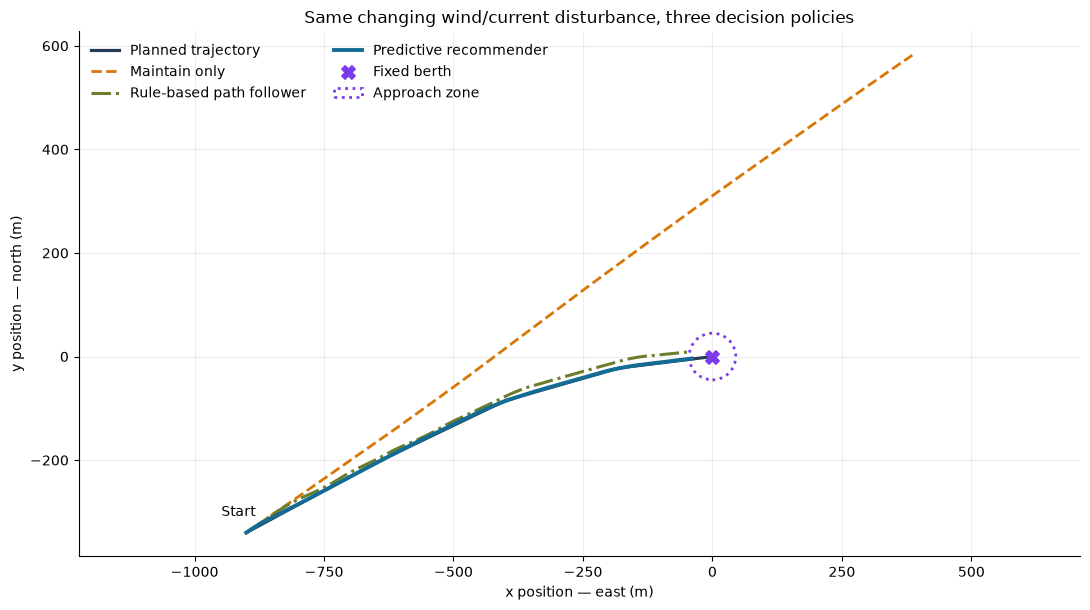

In [6]:
scenario = "changing_wind_current"
maintain_run = runs[(scenario, POLICY_LABELS["maintain"])]
rule_run = runs[(scenario, POLICY_LABELS["rule_based"])]
predictive_run = runs[(scenario, POLICY_LABELS["predictive"])]

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.plot(trajectory.x, trajectory.y, color=COLORS["plan"], lw=2.3, label="Planned trajectory")
ax.plot(maintain_run.x_position_m, maintain_run.y_position_m, "--",
        color=COLORS[POLICY_LABELS["maintain"]], lw=2.0, label=POLICY_LABELS["maintain"])
ax.plot(rule_run.x_position_m, rule_run.y_position_m, "-.",
        color=COLORS[POLICY_LABELS["rule_based"]], lw=2.2, label=POLICY_LABELS["rule_based"])
ax.plot(predictive_run.x_position_m, predictive_run.y_position_m,
        color=COLORS[POLICY_LABELS["predictive"]], lw=2.8, label=POLICY_LABELS["predictive"])
ax.scatter([berth.target_x], [berth.target_y], s=95, marker="X",
           color=COLORS["berth"], label="Fixed berth", zorder=5)
ax.add_patch(Circle((berth.target_x, berth.target_y), berth.approach_zone_radius_m,
                    fill=False, ls=":", lw=2, color=COLORS["berth"], label="Approach zone"))
ax.annotate("Start", (trajectory.iloc[0].x, trajectory.iloc[0].y),
            xytext=(-18, 12), textcoords="offset points")
ax.set(title="Same changing wind/current disturbance, three decision policies",
       xlabel="x position — east (m)", ylabel="y position — north (m)")
ax.legend(frameon=False, ncol=2)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
fig.savefig(ASSETS / "trajectory_tracking_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Cross-Track Error Over Time

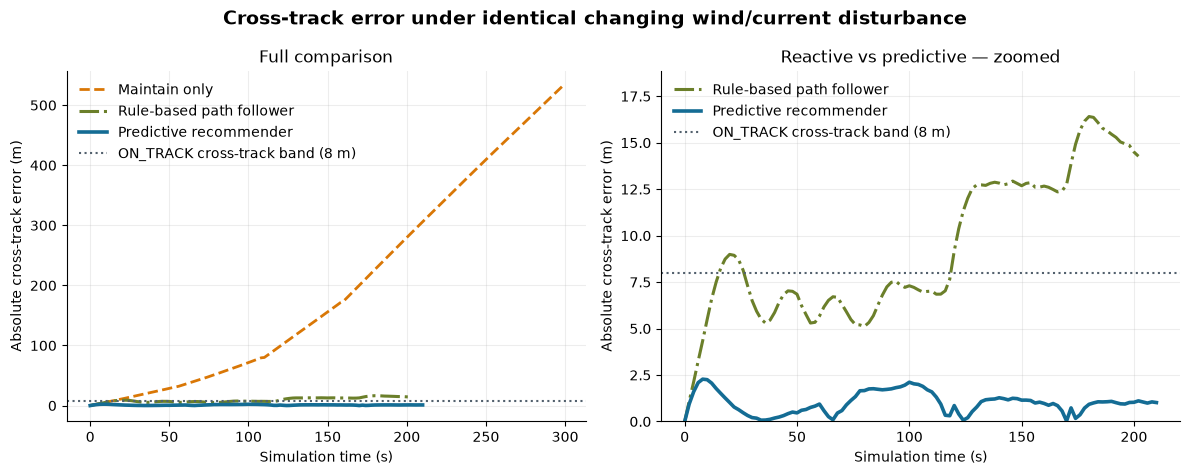

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(maintain_run.timestamp_s, maintain_run.cross_track_error_m.abs(), "--",
             color=COLORS[POLICY_LABELS["maintain"]], lw=2, label=POLICY_LABELS["maintain"])
axes[0].plot(rule_run.timestamp_s, rule_run.cross_track_error_m.abs(), "-.",
             color=COLORS[POLICY_LABELS["rule_based"]], lw=2.2, label=POLICY_LABELS["rule_based"])
axes[0].plot(predictive_run.timestamp_s, predictive_run.cross_track_error_m.abs(),
             color=COLORS[POLICY_LABELS["predictive"]], lw=2.6, label=POLICY_LABELS["predictive"])
axes[0].axhline(8, color="#52606D", ls=":", label="ON_TRACK cross-track band (8 m)")
axes[0].set(title="Full comparison", xlabel="Simulation time (s)", ylabel="Absolute cross-track error (m)")
axes[0].legend(frameon=False)

axes[1].plot(rule_run.timestamp_s, rule_run.cross_track_error_m.abs(), "-.",
             color=COLORS[POLICY_LABELS["rule_based"]], lw=2.2, label=POLICY_LABELS["rule_based"])
axes[1].plot(predictive_run.timestamp_s, predictive_run.cross_track_error_m.abs(),
             color=COLORS[POLICY_LABELS["predictive"]], lw=2.6, label=POLICY_LABELS["predictive"])
axes[1].axhline(8, color="#52606D", ls=":", label="ON_TRACK cross-track band (8 m)")
axes[1].set(title="Reactive vs predictive — zoomed", xlabel="Simulation time (s)", ylabel="Absolute cross-track error (m)")
axes[1].set_ylim(0, 1.15 * rule_run.cross_track_error_m.abs().max())
axes[1].legend(frameon=False)

fig.suptitle("Cross-track error under identical changing wind/current disturbance", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(ASSETS / "cross_track_error_over_time.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Performance and Scenario Comparison

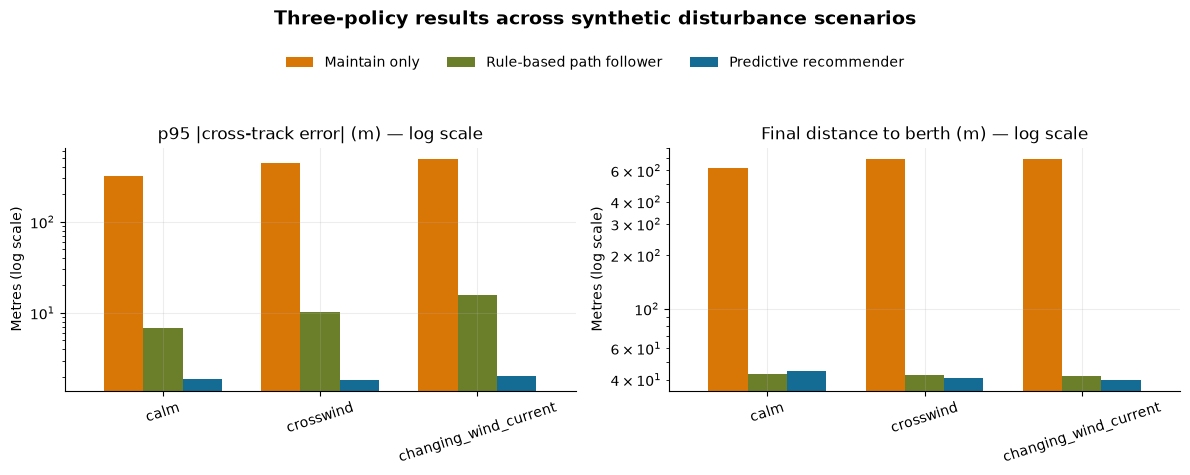

In [8]:
plot_metrics = metrics.copy()
policy_order = [POLICY_LABELS[policy] for policy in POLICIES]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for index, (measure, label) in enumerate([
    ("p95_cross_track_error_m", "p95 |cross-track error| (m)"),
    ("final_position_error_m", "Final distance to berth (m)"),
]):
    pivot = plot_metrics.pivot(index="scenario", columns="controller", values=measure).reindex(SCENARIOS)
    pivot = pivot[policy_order]
    pivot.plot.bar(
        ax=axes[index],
        color=[COLORS[policy] for policy in policy_order],
        width=0.75,
        legend=False,
    )
    axes[index].set_yscale("log")
    axes[index].set(title=f"{label} — log scale", xlabel="", ylabel="Metres (log scale)")
    axes[index].tick_params(axis="x", rotation=18)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 0.91))
fig.suptitle("Three-policy results across synthetic disturbance scenarios", fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.84))
fig.savefig(ASSETS / "scenario_comparison.png", dpi=170, bbox_inches="tight")
plt.show()

In [9]:
action_counts = pd.concat([
    run.assign(run_scenario=scenario)
    for (scenario, controller), run in runs.items()
    if controller != POLICY_LABELS["maintain"]
]).groupby(["run_scenario", "controller", "recommended_action"]).size().unstack(fill_value=0)
display(action_counts)

recommended_action                              CORRECT_PORT  \
run_scenario          controller                               
calm                  Predictive recommender               0   
                      Rule-based path follower             8   
changing_wind_current Predictive recommender               0   
                      Rule-based path follower            36   
crosswind             Predictive recommender               0   
                      Rule-based path follower            26   

recommended_action                              CORRECT_STARBOARD  \
run_scenario          controller                                    
calm                  Predictive recommender                   17   
                      Rule-based path follower                 23   
changing_wind_current Predictive recommender                   20   
                      Rule-based path follower                 55   
crosswind             Predictive recommender                   20   
                      Rule-based path follower                 45   

recommended_action                              INCREASE_SPEED  MAINTAIN  \
run_scenario          controller                                           
calm                  Predictive recommender                 0        67   
                      Rule-based path follower               0        77   
changing_wind_current Predictive recommender                 1        73   
                      Rule-based path follower               0         8   
crosswind             Predictive recommender                 0        73   
                      Rule-based path follower               0        27   

recommended_action                              REDUCE_SPEED  STABILIZE  
run_scenario          controller                                         
calm                  Predictive recommender               0         46  
                      Rule-based path follower            17          2  
changing_wind_current Predictive recommender               4          8  
                      Rule-based path follower             3          0  
crosswind             Predictive recommender               9          3  
                      Rule-based path follower             6          0

## 11. Human in the Loop

The output is **“Recommend CORRECT_PORT”**, not an autonomous command. A pilot or bridge operator may accept or override it. A production record would log the observed state, environment, predicted state, candidate scores, recommendation, reason, operator decision, model/simulator versions, and latency.

## 12. Failure Modes

| Failure mode | Why it matters | Example mitigation |
|---|---|---|
| State-estimation error | GPS/AIS/sensor error corrupts current state | Redundant sensors, plausibility checks |
| Environment error | Wind/current estimates are wrong | Uncertainty bounds, conservative fallback |
| Model error / shift | New vessel or conditions differ from training | Drift detection, simulation tests, versioning |
| Action-model error | Simplified dynamics mis-rank actions | Bounded actions, calibrated vessel model |
| Latency | Advice arrives too late | Latency SLOs, stale-recommendation rejection |
| Trajectory failure | The nominal plan is no longer appropriate | Pilot override and replanning workflow |

## 13. Production and Monitoring Considerations

- **Model:** next-position MAE/RMSE/p95 error and residual drift.
- **Trajectory:** cross-track error, heading error, and final approach-zone error.
- **System:** recommendation latency, availability, and failed predictions.
- **Operations:** correction frequency, override rate, on-track share, and time to zone.
- **Governance:** audit logs, versioned models, bounded actions, and simulation-based release gates.

Real operations remain governed by certified navigation systems, pilots, bridge crew, COLREG/port procedures, vessel-specific dynamics, redundant sensors, and safety systems.

## 14. Final Takeaways

In [10]:
focus = metrics[metrics.scenario.eq("changing_wind_current")].set_index("controller")
maintain = focus.loc[POLICY_LABELS["maintain"]]
reactive = focus.loc[POLICY_LABELS["rule_based"]]
predictive = focus.loc[POLICY_LABELS["predictive"]]
p95_reduction = 100 * (1 - predictive.p95_cross_track_error_m / reactive.p95_cross_track_error_m)
display(Markdown(f"""
- In changing wind/current, mean absolute cross-track error was **{maintain.mean_cross_track_error_m:.1f} m** without control, **{reactive.mean_cross_track_error_m:.1f} m** with reactive rules, and **{predictive.mean_cross_track_error_m:.1f} m** with predictive look-ahead.
- Predictive look-ahead reduced p95 cross-track error by **{p95_reduction:.1f}%** versus the rule-based follower (**{reactive.p95_cross_track_error_m:.1f} m → {predictive.p95_cross_track_error_m:.1f} m**) and used **{predictive.corrective_recommendations:.0f}** corrections instead of **{reactive.corrective_recommendations:.0f}**.
- The reactive follower still reached the zone **{predictive.time_to_approach_zone_s - reactive.time_to_approach_zone_s:.0f} s faster**, showing that it is a credible baseline rather than a straw man.
- The predictive advantage is tighter, less intervention-heavy path tracking—not universally faster arrival. These are synthetic-simulator results, and all actions remain advisory.
"""))


- In changing wind/current, mean absolute cross-track error was **198.9 m** without control, **9.3 m** with reactive rules, and **1.0 m** with predictive look-ahead.
- Predictive look-ahead reduced p95 cross-track error by **87.1%** versus the rule-based follower (**15.7 m → 2.0 m**) and used **33** corrections instead of **94**.
- The reactive follower still reached the zone **8 s faster**, showing that it is a credible baseline rather than a straw man.
- The predictive advantage is tighter, less intervention-heavy path tracking—not universally faster arrival. These are synthetic-simulator results, and all actions remain advisory.
